In [300]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [8]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [24]:
print(sentiment.shape)
print(sentiment.columns)
print(sentiment.duplicated().sum())

(2644, 4)
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
0


In [22]:
print(trades.shape)
print(trades.columns)
print(trades.duplicated().sum())

(211224, 16)
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
0


In [36]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment = sentiment[['date', 'classification']]
print(sentiment)

           date classification
0    2018-02-01           Fear
1    2018-02-02   Extreme Fear
2    2018-02-03           Fear
3    2018-02-04   Extreme Fear
4    2018-02-05   Extreme Fear
...         ...            ...
2639 2025-04-28        Neutral
2640 2025-04-29          Greed
2641 2025-04-30          Greed
2642 2025-05-01        Neutral
2643 2025-05-02          Greed

[2644 rows x 2 columns]


In [44]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
trades['date'] = trades['Timestamp IST'].dt.date
print(trades['date'])

0         2024-12-02
1         2024-12-02
2         2024-12-02
3         2024-12-02
4         2024-12-02
             ...    
211219    2025-04-25
211220    2025-04-25
211221    2025-04-25
211222    2025-04-25
211223    2025-04-25
Name: date, Length: 211224, dtype: object


In [46]:
sentiment['date'] = sentiment['date'].dt.date

In [52]:
merged = trades.merge(sentiment, on='date', how='left')
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [54]:
merged['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [60]:
daily_pnl = merged.groupby(['Account','date']).agg({'Closed PnL': 'sum'}).reset_index()
daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [70]:
trade_count = merged.groupby(['Account','date']).size().reset_index(name='trade_count')
avg_size = merged.groupby(['Account','date'])['Size USD'].mean().reset_index(name='avg_trade_size')

#trade_count.head()

In [74]:
daily_metrics = daily_pnl.merge(trade_count, on=['Account','date'])
daily_metrics = daily_metrics.merge(avg_size, on=['Account','date'])
daily_metrics.head()

,Account,date,Closed PnL,trade_count,avg_trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,5089.718249
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,7976.664412
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,23734.500000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,12,28186.666667
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,27,17248.148148


In [78]:
daily_metrics = daily_metrics.merge(sentiment, on='date', how='left')
daily_metrics.head()

,Account,date,Closed PnL,trade_count,avg_trade_size,classification_x,classification_y
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,5089.718249,Extreme Greed,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,7976.664412,Extreme Greed,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,23734.500000,Extreme Greed,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,12,28186.666667,Extreme Greed,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,27,17248.148148,Extreme Greed,Extreme Greed


In [82]:
daily_metrics['classification'] = daily_metrics['classification_x']
daily_metrics = daily_metrics.drop(columns=['classification_x','classification_y'])
daily_metrics.head()

,Account,date,Closed PnL,trade_count,avg_trade_size,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,5089.718249,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,7976.664412,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,23734.500000,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,12,28186.666667,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,27,17248.148148,Extreme Greed


In [84]:
daily_metrics.groupby('classification')['Closed PnL'].mean().sort_values()

classification
Greed            3318.100730
Neutral          3438.618818
Extreme Fear     4619.439053
Extreme Greed    5161.922644
Fear             5328.818161
Name: Closed PnL, dtype: float64

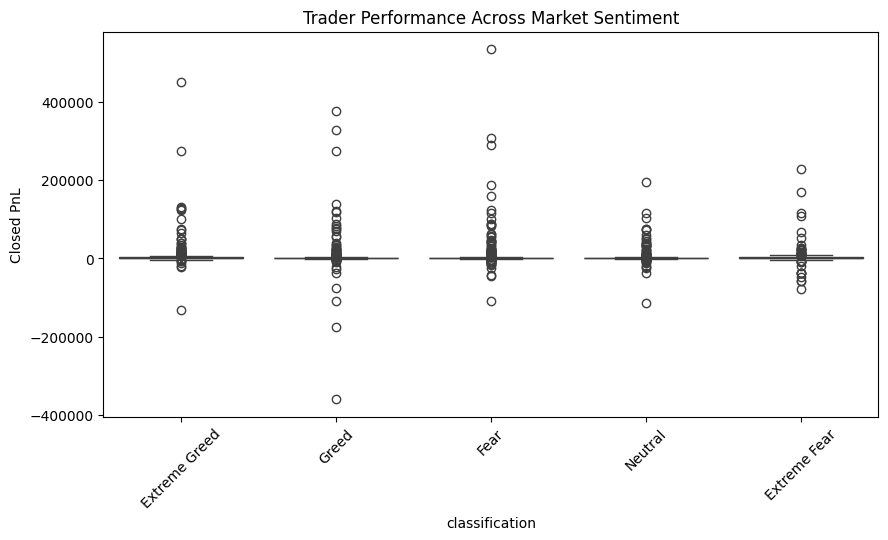

In [86]:
plt.figure(figsize=(10,5))
sns.boxplot(x='classification', y='Closed PnL', data=daily_metrics)
plt.xticks(rotation=45)
plt.title("Trader Performance Across Market Sentiment")
plt.show()

In [90]:
daily_metrics['activity_segment'] = pd.qcut(daily_metrics['trade_count'], q=3, labels=['Low Activity','Medium Activity','High Activity'])
daily_metrics.groupby('activity_segment')['Closed PnL'].mean()

C:\Users\sanka\AppData\Local\Temp\ipykernel_10692\4058814242.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_metrics.groupby('activity_segment')['Closed PnL'].mean()


activity_segment
Low Activity        873.271047
Medium Activity    2997.046608
High Activity      9400.626049
Name: Closed PnL, dtype: float64

In [92]:
daily_metrics.groupby('classification')['trade_count'].mean().sort_values()

classification
Extreme Greed     76.030418
Greed             77.628086
Fear              98.153968
Neutral          100.228723
Extreme Fear     133.750000
Name: trade_count, dtype: float64

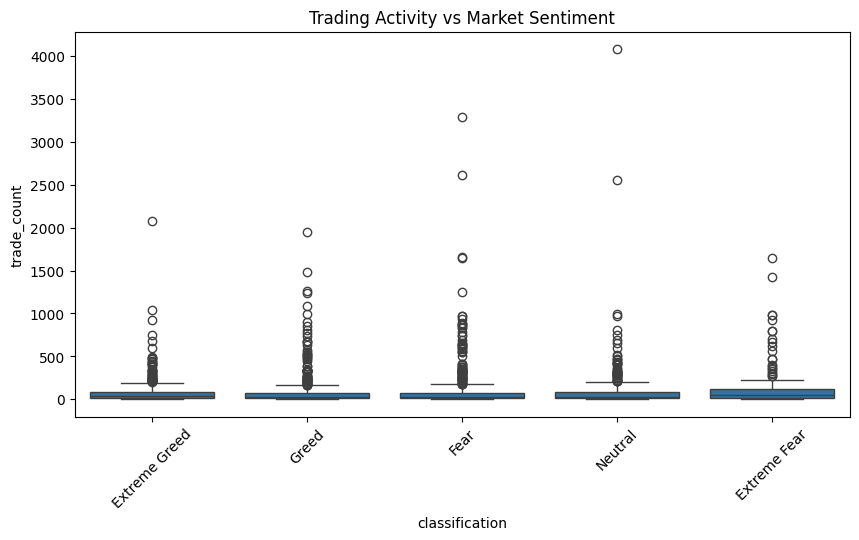

In [94]:
plt.figure(figsize=(10,5))
sns.boxplot(x='classification', y='trade_count', data=daily_metrics)
plt.xticks(rotation=45)
plt.title("Trading Activity vs Market Sentiment")
plt.show()

In [264]:
def pnl_bucket(pnl):
    if pnl < 0:
        return "Loss"
    elif pnl > 0:
        return "Profit"
    else:
        return "Neutral"

daily_metrics['pnl_bucket'] = daily_metrics['Closed PnL'].apply(pnl_bucket)

In [266]:
daily_metrics['pnl_bucket'].value_counts()

pnl_bucket
Profit     1467
Neutral     648
Loss        226
Name: count, dtype: int64

In [268]:
features = [col for col in daily_metrics.columns if col.startswith('classification_')] + ['trade_count','avg_trade_size']

x = daily_metrics[features]
y = daily_metrics['pnl_bucket']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=56)

In [270]:
model = RandomForestClassifier(n_estimators=100, random_state=56)
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [271]:
y_pred = model.predict(x_test)
acc = accuracy_score(y_test, y_pred) * 100
print(f"Model Accuracy: {acc:.2f}%")
print(classification_report(y_test, y_pred))

Model Accuracy: 60.88%
              precision    recall  f1-score   support

        Loss       0.07      0.04      0.05        77
     Neutral       0.48      0.43      0.45       188
      Profit       0.70      0.79      0.74       438

    accuracy                           0.61       703
   macro avg       0.42      0.42      0.41       703
weighted avg       0.57      0.61      0.59       703



In [274]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[  3,  18,  56],
       [ 16,  80,  92],
       [ 23,  70, 345]], dtype=int64)

In [276]:
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
cm_percent

array([[ 3.8961039 , 23.37662338, 72.72727273],
       [ 8.5106383 , 42.55319149, 48.93617021],
       [ 5.25114155, 15.98173516, 78.76712329]])

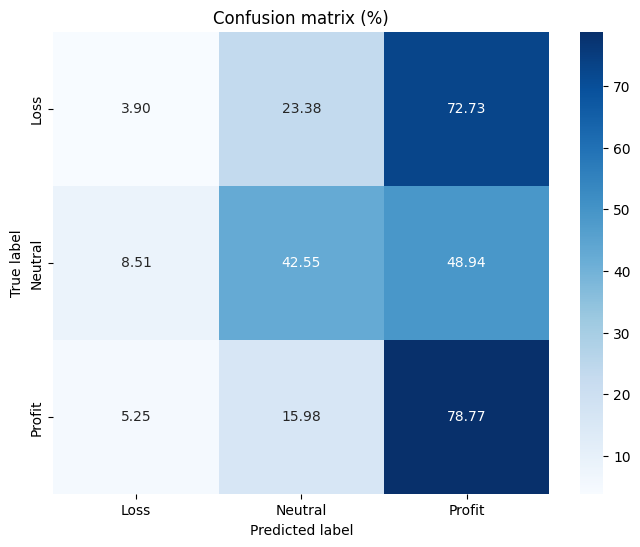

In [280]:
labels = model.classes_

plt.figure(figsize=(8,6))
sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix (%)")
plt.show()

In [282]:
trader_features = daily_metrics.groupby('Account').agg({'Closed PnL': 'mean', 'trade_count': 'mean', 'avg_trade_size': 'mean' }).reset_index()

In [286]:
scaler = StandardScaler()

X = trader_features[['Closed PnL','trade_count','avg_trade_size']]
X_scaled = scaler.fit_transform(X)

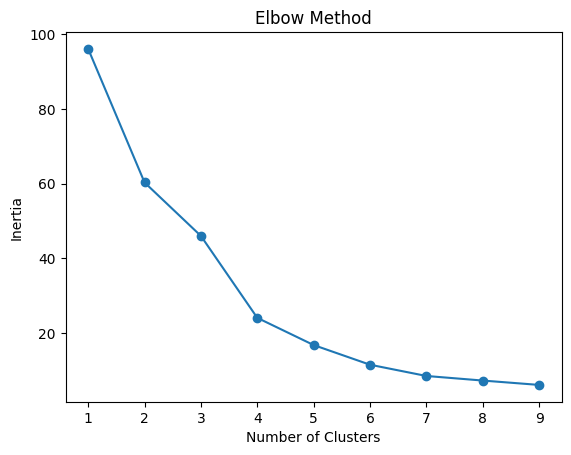

In [290]:
inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [292]:
kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(X_scaled)

In [296]:
cluster_summary = trader_features.groupby('cluster').mean(numeric_only=True)
cluster_summary

,Closed PnL,trade_count,avg_trade_size
cluster,,,
0,9357.930395,198.293709,17045.571443
1,3255.677883,69.546879,3720.372951
2,66676.242499,159.083333,33569.102224


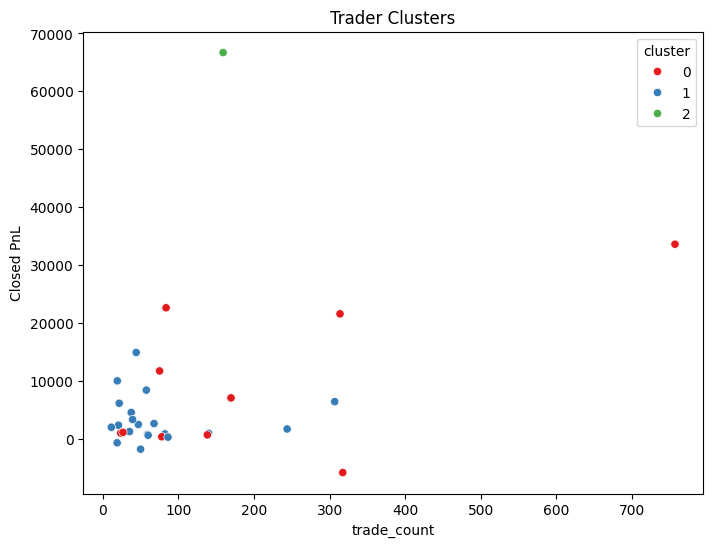

In [298]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='trade_count', y='Closed PnL', hue='cluster', data=trader_features, palette='Set1')

plt.title("Trader Clusters")
plt.show()

In [302]:
score = silhouette_score(X_scaled, trader_features['cluster'])
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.415
